# Impact Energy and Diameter Calculations

Estimates the seismic energy delivered to Bennu by impacts, the minimum
impactor size needed to trigger global regolith mobilisation, and the
reduction in core slant height after successive landslide events.

References:
- Rich (2020): impact seismic shaking on Eros, Steins, Itokawa
- Bottke (2005): main-belt impactor size distribution
- Balouz (2020): Bennu's collisional lifetime

In [1]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 12})

## Physical Constants and Bennu Properties

In [2]:
G     = 6.67408e-11   # gravitational constant (SI)

rho_a = 1260          # Bennu bulk density (kg/m^3)
D_a   = 520           # Bennu mean diameter (m)
R_a   = D_a / 2 / 1000   # Bennu radius (km)

## Seismic Energy Threshold

Minimum energy needed to produce 1 g_a surface acceleration (Quillen's criterion).

In [3]:
f_char = 0.4              # Bennu characteristic frequency (Hz)
f      = 0.41 * f_char    # Quillen critical frequency

E_seismic = (np.pi * G**2 * rho_a**3 * D_a**5) / (108.0 * f**2)
print(f'Seismic energy threshold E_s = {E_seismic:.2f} J')

Seismic energy threshold E_s = 366.40 J


## Minimum Impactor Diameter

Smallest impactor that delivers seismic energy >= E_seismic (Rich 2005).

In [4]:
rho_p = 2700      # impactor density (kg/m^3)
v_p   = 10e3      # typical impact velocity (m/s)
n_eff = 1e-7      # seismic efficiency (Rich 2020)

D_p = np.cbrt(G**2 * rho_a**3 * D_a**5
              / (9.0 * n_eff * rho_p * v_p**2 * f**2)) / 1000   # km

print(f'Minimum impactor diameter D_p = {D_p*1000:.1f} m  ({D_p:.4f} km)')

Minimum impactor diameter D_p = 0.4 m  (0.0004 km)


## Expected Number of Qualifying Impacts

Using main-belt impactor size distribution (Bottke 2005) and Bennu's
collisional lifetime (Balouz 2020).

In [5]:
N     = 2.8e6 * D_p**(-2.2)   # number of main-belt impactors with diam > D_p
mcl_b = 65e6                   # Bennu MBA collisional lifetime (yr)
pi_p  = 2.9e-18               # intrinsic collision probability (km^-2 yr^-1)

n_impact = pi_p * R_a**2 * N * mcl_b
print(f'Expected qualifying impacts over MBA lifetime: {n_impact:.1f}')

Expected qualifying impacts over MBA lifetime: 1244.6


## Core Slant Height Reduction

Each landslide event erodes the cone by `2 * aspect_ratio * regolith_depth`
in slant height (from the conservation of mass in bennu_solver.cpp).

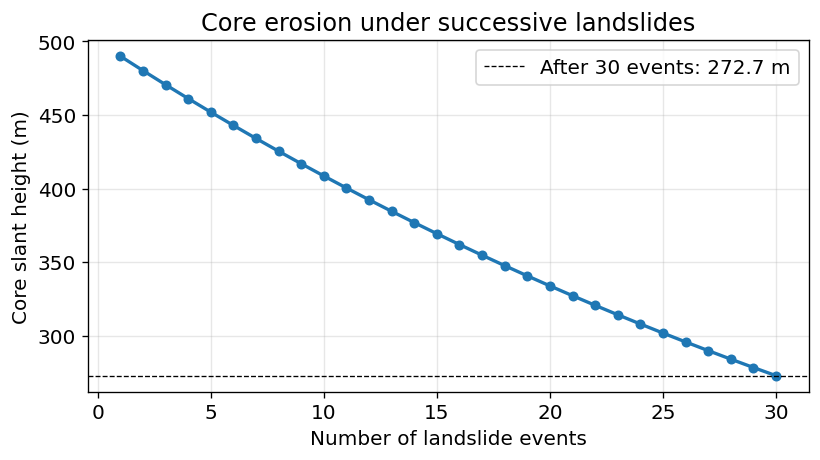

Initial slant height : 500 m
After 30 events: 272.7 m  (45.5% reduction)


In [6]:
slant_0      = 500          # initial core slant height (m)
aspect_ratio = 0.01         # flow aspect ratio epsilon
n_slides     = np.arange(1, 31)

slant_heights = slant_0 * (1.0 - 2.0 * aspect_ratio) ** n_slides

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(n_slides, slant_heights, linewidth=2, marker='o', markersize=5)
ax.axhline(slant_heights[-1], color='k', linestyle='--', linewidth=0.8,
           label=f'After {n_slides[-1]} events: {slant_heights[-1]:.1f} m')
ax.set_xlabel('Number of landslide events')
ax.set_ylabel('Core slant height (m)')
ax.set_title('Core erosion under successive landslides')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Initial slant height : {slant_0} m')
print(f'After {n_slides[-1]} events: {slant_heights[-1]:.1f} m  '
      f'({100*(1 - slant_heights[-1]/slant_0):.1f}% reduction)')